In [1]:
import numpy as np
import pandas as pd
import math
import yfinance as yf
from scipy.stats import norm, chi2, skew, kurtosis
import matplotlib.pyplot as plt

#### Integrantes:
#### Ascencio Díaz Enrique
#### Lugo Salazar María Inés
#### Martínez Pineda Alison Azul
#### Ordáz López Julio César
#### Rivera Hernández Ollin César



# 1. Función con API de yf para obtener cotizaciónes y log-Retornos


In [2]:
def coti_logr(activos,fi,ff):
  df_precios = yf.download(
    tickers=activos,
    start= fi,
    end= ff)

  df_precios = df_precios["Close"].dropna()
  df_precios.index = df_precios.index.date
  df_precios.index = pd.to_datetime(df_precios.index)

  for i in activos:
    df_precios[f"ri_{i}"]=np.log(df_precios[i]).diff()

  df_precios = df_precios.dropna()
  return df_precios

# 2. Tabla comparativa de estadísticos e histogramas

In [3]:
def prueba_jarque_bera_df(df, alpha):
    ri_cols = [col for col in df.columns if col.startswith("ri_")]

    resultados = []

    for col in ri_cols:
        rend = df[col].dropna()
        n = len(rend)
        if n < 3:
            resultados.append([col.replace("ri_", ""), None, None, None, None, "Datos insuficientes"])
            continue

        miu = rend.mean()
        DE = math.sqrt(((rend - miu)**2).sum() / (n - 1))
        S = (n / ((n - 1) * (n - 2))) * (((rend - miu) / DE)**3).sum() 
        K = (((rend - miu)**4).sum()) / ((n - 1) * (DE**4))            
        JB = n * ((S**2) / 6 + ((K - 3)**2) / 24)
        p_value = chi2.sf(JB, 2)

        decision = "Se acepta H0" if p_value > alpha else "Se rechaza H0"

        resultados.append([col.replace("ri_", ""), S, K, JB, p_value, decision])

    jb_tabla = pd.DataFrame(
        resultados,
        columns=["Ticker", "Sesgo", "Kurtosis", "Estadistico JB", "p-value", "Resultado"])

    return jb_tabla

In [4]:
def graficar_histogramas(df, tickers):
    columnas = [f"ri_{t}" for t in tickers if f"ri_{t}" in df.columns]

    if not columnas:
        print("No se encontraron columnas 'ri_' correspondientes a los tickers proporcionados.")
        return

    largo = len(df)
    c = math.ceil(math.log(largo, 2))

    n_cols = 2
    n_rows = math.ceil(len(columnas) / n_cols)
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(columnas):  #curva normal
        serie = df[col].dropna()
        nombre = col.replace('ri_', '')

        # parametros de la distribución normal
        mu, sigma = serie.mean(), serie.std()

        # Histograma normalizado (densidad)
        axes[i].hist(
            serie,
            bins=c,
            density=True,           
            color='skyblue',
            edgecolor='black',
            alpha=0.7
        )

        x = np.linspace(serie.min(), serie.max(), 200)
        y = norm.pdf(x, mu, sigma)
        axes[i].plot(x, y, 'r', lw=2, label='Curva normal teórica')

        axes[i].set_title(f"Histograma de {nombre}\nμ = {mu:.4f}, σ = {sigma:.4f}")
        axes[i].set_xlabel("Rendimientos")
        axes[i].set_ylabel("Densidad")
        axes[i].legend()

    for j in range(len(columnas), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# 3. Volatilidad WMA y EWMA

In [5]:
def calculo_volatilidades(df, ventana=100, lamda=0.94):
    def std_wma(ri):
        ri = pd.Series(ri).dropna()
        n = len(ri)
        if n == 0:
            return np.nan
        i = np.arange(1, n + 1)
        wi = i / i.sum()
        media = ri.mean()
        var_ponderada = np.sum(((ri - media) ** 2) * wi)
        return np.sqrt(var_ponderada)

    ri_cols = [c for c in df.columns if c.startswith('ri_')]

    # --- WMA ---
    for col in ri_cols:
        ri_shifted = df[col].shift(1)
        vals = []
        for i in range(len(df)):
            if i >= ventana - 1:
                ventana_ri = ri_shifted.iloc[i - ventana + 1 : i + 1]
                vals.append(std_wma(ventana_ri))
            else:
                vals.append(np.nan)
        df[f"VWMA_{col.replace('ri_', '')}"] = vals

    # --- EWMA ---
    for col in ri_cols:
        r = df[col]
        vol = [abs(r.iloc[0]) ** 2]
        for i in range(1, len(r)):
            vol_t = (1 - lamda) * (r.iloc[i - 1] ** 2) + lamda * vol[-1]
            vol.append(vol_t)
        df[f"VEWMA_{col.replace('ri_', '')}"] = [math.sqrt(v) for v in vol]

    return df

# 4. Gráfica de volatilidades


In [6]:
def graficar_volatilidades(df, tickers, ventana=100):

    colores = ['tab:orange', 'tab:green', 'tab:red', 'tab:blue',
               'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
    n_cols = 2
    n_rows = math.ceil(len(tickers) / n_cols)
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 4 * n_rows))
    axes = axes.flatten()

    for i, ticker in enumerate(tickers):
        col_wma = f"VWMA_{ticker}"
        col_ewma = f"VEWMA_{ticker}"
        color_base = colores[i % len(colores)]  

        if col_wma not in df.columns or col_ewma not in df.columns:
            axes[i].text(0.5, 0.5, f"No existe {ticker}", ha='center', va='center')
            axes[i].axis('off')
            continue

        axes[i].plot(df[col_wma], color=color_base, label='WMA')
        axes[i].plot(df[col_ewma], color=color_base, alpha=0.5, label='EWMA')

        axes[i].set_title(f"Método dinámico WMA / EWMA - {ticker}")
        axes[i].set_xlabel("Fecha")
        axes[i].set_ylabel("Volatilidad (ri/vol)")
        axes[i].legend()

    for j in range(len(tickers), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# 5. VaR paramétrico e histórico

In [7]:
def calcular_VaR_total_simple(df, alpha=0.99, ventana_vol=100, ventana_hist=252):
    z = -norm.ppf(1 - alpha)  # valor crítico normal
    q = 1 - alpha

    ri_cols = [c for c in df.columns if c.startswith('ri_')]
    tickers = [c.replace('ri_', '') for c in ri_cols]

    # VAR PARAMETRICO CON WMA
    for t in tickers:
        col_wma = f"VWMA_{t}"
        if col_wma not in df.columns or t not in df.columns:
            continue
        St = df[t].ffill()
        sigma = df[col_wma]

        df[f"VaRP_WMA_1d_{t}"]   = -St * sigma * z
        df[f"VaRP_WMA_30d_{t}"]  = -St * sigma * z * np.sqrt(30)
        df[f"VaRP_WMA_252d_{t}"] = -St * sigma * z * np.sqrt(252)

    # VAR PARAMÉTRICO CON EWMA
    for t in tickers:
        col_ewma = f"VEWMA_{t}"
        if col_ewma not in df.columns or t not in df.columns:
            continue
        St = df[t].ffill()
        sigma = df[col_ewma]

        df[f"VaRP_EWMA_1d_{t}"]   = -St * sigma * z
        df[f"VaRP_EWMA_30d_{t}"]  = -St * sigma * z * np.sqrt(30)
        df[f"VaRP_EWMA_252d_{t}"] = -St * sigma * z * np.sqrt(252)

    # VAR HISTORICO SIMPLE

    for t in tickers:
        col_ri = f"ri_{t}"
        if col_ri not in df.columns or t not in df.columns:
            continue

        ri = df[col_ri]
        St = df[t].ffill()
        
        q_r = ri.rolling(ventana_hist).quantile(q)
        df[f"VaRH_1d_{t}"]   = -St * q_r
        df[f"VaRH_30d_{t}"]  = -St * q_r * np.sqrt(30)
        df[f"VaRH_252d_{t}"] = -St * q_r * np.sqrt(252)

    return df

# 6. Portafolio min. varianza

In [20]:
def resumen_portafolio(df, tickers, pesos, capital_total):

    if not np.isclose(sum(pesos), 1, atol=1e-4):
        print("Advertencia: los pesos no suman 1 (se normalizarán automáticamente).")
        pesos = np.array(pesos) / np.sum(pesos)

    capital_asignado, precios, titulos, ajustado = [], [], [], []

    for i, t in enumerate(tickers):
        if t not in df.columns:
            print(f"⚠️ {t} no está en el DataFrame, se omite.")
            continue

        precio_actual = df[t].ffill().iloc[-1]       # último precio 
        cap_asig = capital_total * pesos[i]          # capital asignado
        num_tit = cap_asig / precio_actual           # número de títulos
        val_ajus = num_tit * precio_actual           # monto real (capital asignado)

        precios.append(precio_actual)
        capital_asignado.append(cap_asig)
        titulos.append(num_tit)
        ajustado.append(val_ajus)

    # Crear el DataFrame resumen
    resumen = pd.DataFrame({
        "Ticker": tickers,
        "Wi": pesos,
        "Capital Asignado": capital_asignado,
        "Ultimo Precio": precios,
        "# Activos": titulos,
        "Monto Real": ajustado
    })

    # Ajustar formato de salida
    resumen["Wi"] = resumen["Wi"].round(4)
    resumen["Capital Asignado"] = resumen["Capital Asignado"].round(2)
    resumen["Ultimo Precio"] = resumen["Ultimo Precio"].round(2)
    resumen["# Activos"] = resumen["# Activos"].round(2)
    resumen["Monto Real"] = resumen["Monto Real"].round(2)

    return resumen


In [42]:
import numpy as np
import pandas as pd

def portafolio_min_varianza(df, tickers, capital_total):
    #rendimientos
    ri_cols = [f"ri_{t}" for t in tickers]
    rend = df[ri_cols].dropna()

    # Matriz de covarianzas
    V = np.cov(rend.T)
    V_inv = np.linalg.inv(V)
    ones = np.ones(len(tickers))

    # Pesos de mínima varianza
    w = (V_inv @ ones) / (ones.T @ V_inv @ ones)

    resumen = resumen_portafolio(df, tickers, w, capital_total)

    return resumen


# 7. VaR conjunto

In [63]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def calcular_VaR_portafolio(df, portafolio_minvar, capital=1_000_000, alpha=0.99):

    z = norm.ppf(1 - alpha)
    q = 1 - alpha
    tickers = portafolio_minvar["Ticker"].tolist()
    w_port = portafolio_minvar.set_index("Ticker")["Wi"].astype(float).values

    ri_cols = [c for c in df.columns if c.startswith("ri_")]
    RI_all = df[ri_cols].dropna().copy()
    RI_all.columns = [c.replace("ri_", "") for c in ri_cols]
    RI_all = RI_all[tickers]

    rp = RI_all @ w_port  # rendimiento diario del portafolio

    var_hist_1d = -capital * rp.quantile(q)
    var_hist_30d = var_hist_1d * np.sqrt(30)
    var_hist_252d = var_hist_1d * np.sqrt(252)

    # VaR usando volatilidad WMA ---
    wma_cols = [c for c in df.columns if c.startswith("VWMA_")]
    VWMA_df = df[wma_cols].dropna().copy()
    VWMA_df.columns = [c.replace("VWMA_", "") for c in wma_cols]
    VWMA_df = VWMA_df[tickers]

    vol_port_wma = np.sqrt((VWMA_df**2 @ w_port**2))
    VaR_WMA_1d   = -capital * vol_port_wma * z
    VaR_WMA_30d  = VaR_WMA_1d * np.sqrt(30)
    VaR_WMA_252d = VaR_WMA_1d * np.sqrt(252)

    # VaR usando volatilidad EWMA ---
    ewma_cols = [c for c in df.columns if c.startswith("VEWMA_")]
    VEWMA_df = df[ewma_cols].dropna().copy()
    VEWMA_df.columns = [c.replace("VEWMA_", "") for c in ewma_cols]
    VEWMA_df = VEWMA_df[tickers]

    vol_port_ewma = np.sqrt((VEWMA_df**2 @ w_port**2))
    VaR_EWMA_1d   = -capital * vol_port_ewma * z
    VaR_EWMA_30d  = VaR_EWMA_1d * np.sqrt(30)
    VaR_EWMA_252d = VaR_EWMA_1d * np.sqrt(252)

    # Tabla final 
    VaR_port_table = pd.DataFrame({
        "Horizonte": ["1 día", "30 días", "252 días"],
        "VaR Historico": [var_hist_1d, var_hist_30d, var_hist_252d],
        "VaR WMA": [
            VaR_WMA_1d.iloc[-1],
            VaR_WMA_30d.iloc[-1],
            VaR_WMA_252d.iloc[-1]
        ],
        "VaR EWMA": [
            VaR_EWMA_1d.iloc[-1],
            VaR_EWMA_30d.iloc[-1],
            VaR_EWMA_252d.iloc[-1]
        ]
    })

    # Formato
    for c in ["VaR Historico", "VaR WMA", "VaR EWMA"]:
        VaR_port_table[c] = VaR_port_table[c].apply(lambda x: f"${x:,.2f}")

    return VaR_port_table


# Llamado de resultados

In [64]:
activos = ['FEMSAUBD.MX','GFINBURO.MX','LIVEPOLC-1.MX','BBVAMRFC.MX'] #Activos seleccionados
f_inicial = "2023-09-28" #fecha inicial de precios históricos
f_final = "2025-09-26"   #fecha final de precios históricos
alpha_jb = 0.05  #Para prueba jarque-bera
ventana = 100 # Para calculo de VaR y volatilidades
parametro_lamb = 0.94 #Para EWMA
capital = 1000000 #Capital del portafolio
alpha_var = 0.99

Dataframe_prin = coti_logr(activos,f_inicial,f_final)
Dataframe_prin.head()

C:\Users\Maria\AppData\Local\Temp\ipykernel_2088\3691978351.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_precios = yf.download(
[*********************100%***********************]  4 of 4 completed


Ticker,BBVAMRFC.MX,FEMSAUBD.MX,GFINBURO.MX,LIVEPOLC-1.MX,ri_FEMSAUBD.MX,ri_GFINBURO.MX,ri_LIVEPOLC-1.MX,ri_BBVAMRFC.MX
2023-09-29,13.80020,172.346817,33.597458,86.520287,0.004696,-0.015926,-0.005139,0.003554
2023-10-02,13.81117,177.590332,33.842625,87.165245,0.029971,0.007271,0.007427,0.000795
2023-10-03,13.81053,176.846451,33.744560,86.434914,-0.004198,-0.002902,-0.008414,-0.000046
2023-10-04,13.81847,177.209320,33.342487,85.998619,0.002050,-0.011987,-0.005060,0.000575
2023-10-05,13.84592,173.970688,33.724945,85.619225,-0.018445,0.011405,-0.004421,0.001984


In [65]:
comparativo_est = prueba_jarque_bera_df(Dataframe_prin,alpha_jb)
comparativo_est

,Ticker,Sesgo,Kurtosis,Estadístico JB,p-value,Resultado Prueba
0,FEMSAUBD.MX,-0.712484,10.390280,1168.339866,1.987108e-254,Se rechaza H0
1,GFINBURO.MX,0.009185,4.665792,57.238504,3.722346e-13,Se rechaza H0
2,LIVEPOLC-1.MX,-0.418355,7.447504,422.407727,1.885070e-92,Se rechaza H0
3,BBVAMRFC.MX,0.505120,6.063125,214.568490,2.552962e-47,Se rechaza H0


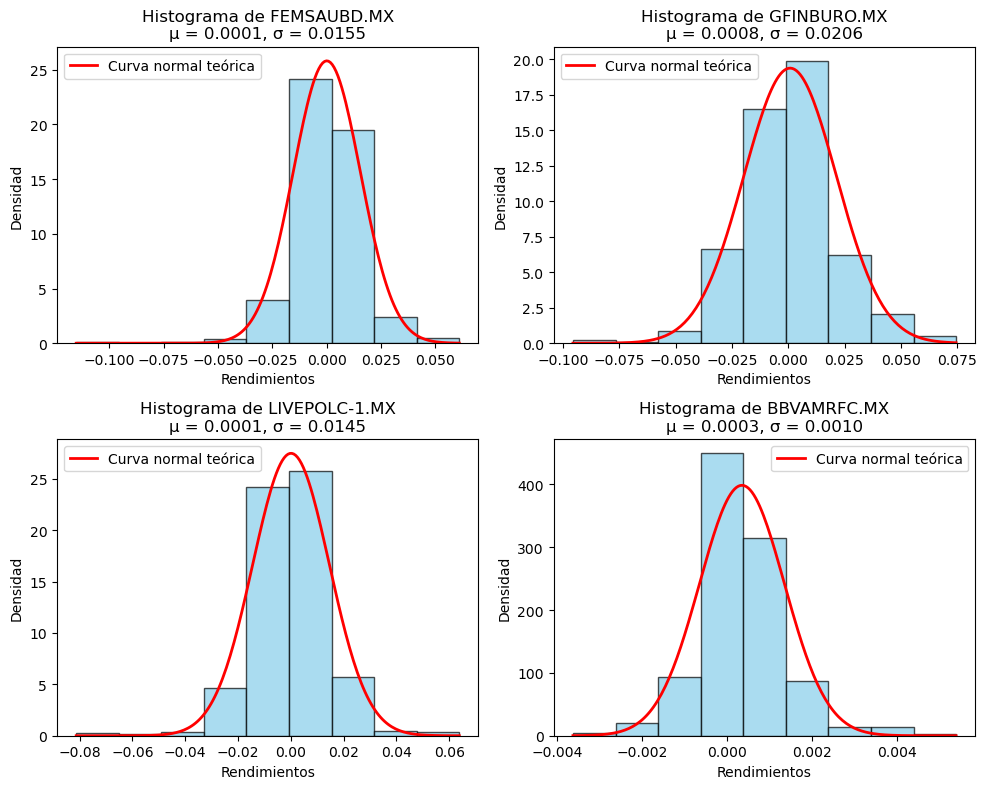

In [66]:
graficar_histogramas(Dataframe_prin,activos)

In [67]:
Dataframe_prin = calculo_volatilidades(Dataframe_prin,ventana,parametro_lamb)

In [68]:
Dataframe_prin.tail()

Ticker,BBVAMRFC.MX,FEMSAUBD.MX,GFINBURO.MX,LIVEPOLC-1.MX,ri_FEMSAUBD.MX,ri_GFINBURO.MX,ri_LIVEPOLC-1.MX,ri_BBVAMRFC.MX,VWMA_FEMSAUBD.MX,VWMA_GFINBURO.MX,VWMA_LIVEPOLC-1.MX,VWMA_BBVAMRFC.MX,VEWMA_FEMSAUBD.MX,VEWMA_GFINBURO.MX,VEWMA_LIVEPOLC-1.MX,VEWMA_BBVAMRFC.MX
2025-09-19,16.301291,177.020004,50.799999,91.962975,0.037997,-0.033488,-0.003106,0.001086,0.014511,0.016353,0.011274,0.000386,0.015758,0.014785,0.008261,0.000577
2025-09-22,16.306311,178.089996,51.520000,92.742401,0.006026,0.014074,0.008440,0.000308,0.015401,0.016845,0.011145,0.000396,0.017889,0.016516,0.008045,0.000619
2025-09-23,16.315180,180.429993,52.340000,93.600769,0.013054,0.015791,0.009213,0.000544,0.015278,0.016752,0.011061,0.000392,0.017407,0.016379,0.008069,0.000605
2025-09-24,16.322371,180.360001,51.320000,92.791740,-0.000388,-0.019680,-0.008681,0.000441,0.015270,0.016683,0.010987,0.000389,0.017177,0.016345,0.008142,0.000602
2025-09-25,16.332251,179.240005,51.830002,91.597923,-0.006229,0.009889,-0.012949,0.000605,0.015151,0.016732,0.010918,0.000384,0.016654,0.016564,0.008176,0.000593


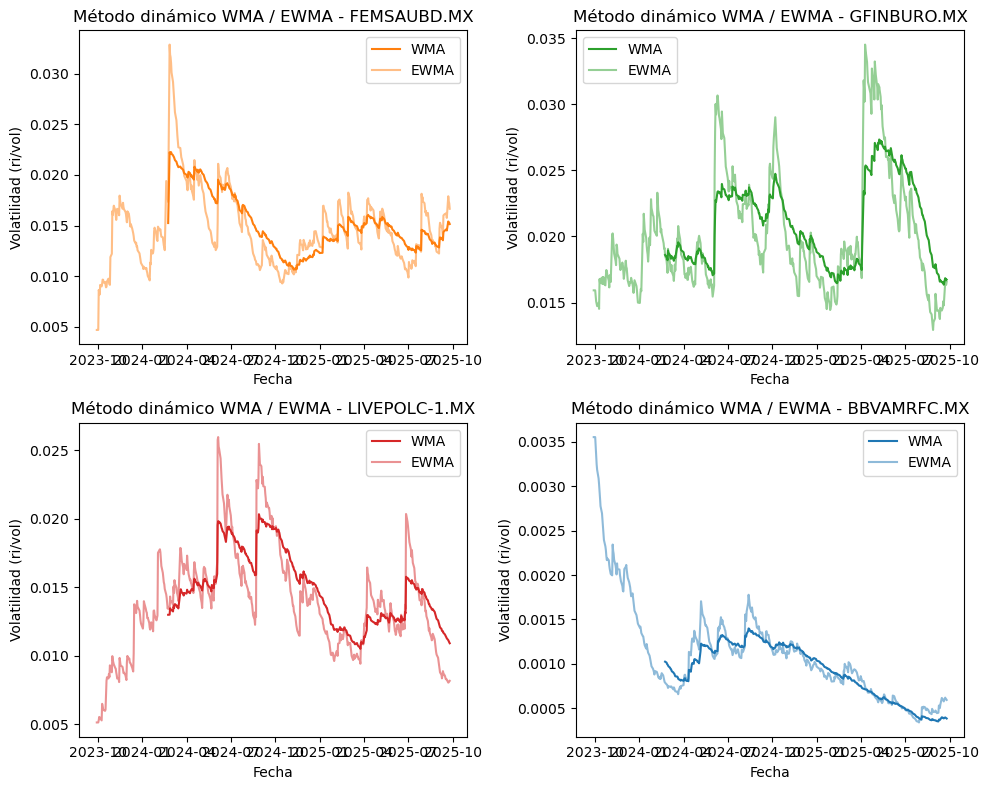

In [69]:
graficar_volatilidades(Dataframe_prin,activos)

In [70]:
Dataframe_prin = calcular_VaR_total_simple(Dataframe_prin,alpha_var,ventana)
Dataframe_prin.tail()

Ticker,BBVAMRFC.MX,FEMSAUBD.MX,GFINBURO.MX,LIVEPOLC-1.MX,ri_FEMSAUBD.MX,ri_GFINBURO.MX,ri_LIVEPOLC-1.MX,ri_BBVAMRFC.MX,VWMA_FEMSAUBD.MX,VWMA_GFINBURO.MX,...,VaRH_252d_FEMSAUBD.MX,VaRH_1d_GFINBURO.MX,VaRH_30d_GFINBURO.MX,VaRH_252d_GFINBURO.MX,VaRH_1d_LIVEPOLC-1.MX,VaRH_30d_LIVEPOLC-1.MX,VaRH_252d_LIVEPOLC-1.MX,VaRH_1d_BBVAMRFC.MX,VaRH_30d_BBVAMRFC.MX,VaRH_252d_BBVAMRFC.MX
2025-09-19,16.301291,177.020004,50.799999,91.962975,0.037997,-0.033488,-0.003106,0.001086,0.014511,0.016353,...,105.534589,2.489474,13.635411,39.519175,2.606631,14.277105,41.378982,0.024444,0.133885,0.388035
2025-09-22,16.306311,178.089996,51.520000,92.742401,0.006026,0.014074,0.008440,0.000308,0.015401,0.016845,...,106.172489,2.524758,13.828669,40.079291,2.628723,14.398110,41.729688,0.024451,0.133926,0.388154
2025-09-23,16.315180,180.429993,52.340000,93.600769,0.013054,0.015791,0.009213,0.000544,0.015278,0.016752,...,107.567533,2.564942,14.048768,40.717198,2.653053,14.531370,42.115912,0.024465,0.133999,0.388366
2025-09-24,16.322371,180.360001,51.320000,92.791740,-0.000388,-0.019680,-0.008681,0.000441,0.015270,0.016683,...,107.525805,2.514957,13.774986,39.923703,2.630122,14.405770,41.751888,0.024476,0.134058,0.388537
2025-09-25,16.332251,179.240005,51.830002,91.597923,-0.006229,0.009889,-0.012949,0.000605,0.015151,0.016732,...,106.858094,2.539950,13.911878,40.320452,2.596284,14.220432,41.214727,0.024490,0.134139,0.388772


In [71]:
df_port_minvar = portafolio_min_varianza(Dataframe_prin,activos,capital)
df_port_minvar

,Ticker,Wi,Capital Asignado,Ultimo Precio,# Activos,Monto Real
0,FEMSAUBD.MX,0.0050,5004.23,179.24,27.92,5004.23
1,GFINBURO.MX,0.0010,1041.45,51.83,20.09,1041.45
2,LIVEPOLC-1.MX,0.0025,2515.06,91.60,27.46,2515.06
3,BBVAMRFC.MX,0.9914,991439.26,16.33,60704.39,991439.26


In [72]:
calcular_VaR_portafolio(Dataframe_prin,df_port_minvar,capital,alpha_var)

,Horizonte,VaR Historico,VaR WMA,VaR EWMA
0,1 día,"$2,106.84",$906.84,"$1,383.38"
1,30 días,"$11,539.62","$4,966.99","$7,577.07"
2,252 días,"$33,445.00","$14,395.70","$21,960.43"
